In [2]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.callbacks import EarlyStopping

plt.rcParams["figure.figsize"] = [15, 6]


In [28]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
# Шлях до даних
DATA_DIR = Path("data/subset_homework")

if not DATA_DIR.exists():
    raise FileNotFoundError(f"Папку не знайдено: {DATA_DIR.resolve()}")

class_dirs = sorted(
    [p for p in DATA_DIR.iterdir()
     if p.is_dir() and p.name.split("_")[-1].isdigit()],
    key=lambda p: int(p.name.split("_")[-1])
)

print("Знайдені класи:")
for i, p in enumerate(class_dirs):
    print(i, "->", p.name)

num_classes = len(class_dirs)
print("Кількість класів:", num_classes)
# Завантаження зображень
images = []
labels = []
class_names = []

valid_ext = {".png", ".jpg", ".jpeg", ".bmp", ".ppm"}

target_size = None   # якщо всі картинки однакового розміру, resize не потрібен

for class_idx, class_dir in enumerate(class_dirs):
    class_names.append(class_dir.name)
    
    files = sorted([f for f in class_dir.iterdir() if f.suffix.lower() in valid_ext])
    
    for file in files:
        img = cv2.imread(str(file), cv2.IMREAD_GRAYSCALE)
        
        if img is None:
            print("Не вдалося прочитати:", file)
            continue
        
        # Запам'ятовуємо розмір першого зображення
        if target_size is None:
            target_size = (img.shape[1], img.shape[0])  # width, height
        
        # Якщо раптом розміри різні — приводимо до одного
        if (img.shape[1], img.shape[0]) != target_size:
            img = cv2.resize(img, target_size)
        
        images.append(img)
        labels.append(class_idx)

images = np.array(images)
labels = np.array(labels)


Знайдені класи:
0 -> class_id_0
1 -> class_id_1
Кількість класів: 2


Images shape: (4470, 28, 28)
Labels shape: (4470,)
Image min/max: 2 255


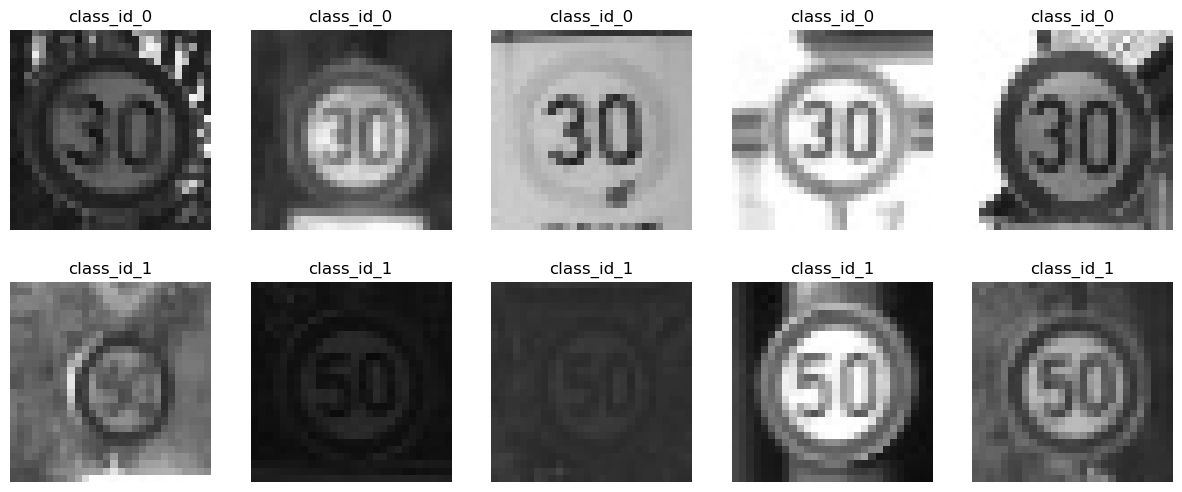

In [29]:
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Image min/max:", images.min(), images.max())
# Скільки зображень у кожному класі?
counts = pd.DataFrame({
    "class_index": range(num_classes),
    "class_name": class_names,
    "num_images": [np.sum(labels == i) for i in range(num_classes)]
})

counts
# Візуалізація кількох прикладів з кожного класу
samples_per_class = 5

plt.figure(figsize=(samples_per_class * 3, num_classes * 3))

plot_idx = 1

for class_idx in range(num_classes):
    idxs = np.where(labels == class_idx)[0]
    chosen = np.random.choice(
        idxs, 
        size=min(samples_per_class, len(idxs)), 
        replace=False
    )
    
    for idx in chosen:
        plt.subplot(num_classes, samples_per_class, plot_idx)
        plt.imshow(images[idx], cmap="gray", vmin=0, vmax=255)
        plt.title(f"{class_names[class_idx]}")
        plt.axis("off")
        plot_idx += 1



<Figure size 1500x600 with 0 Axes>

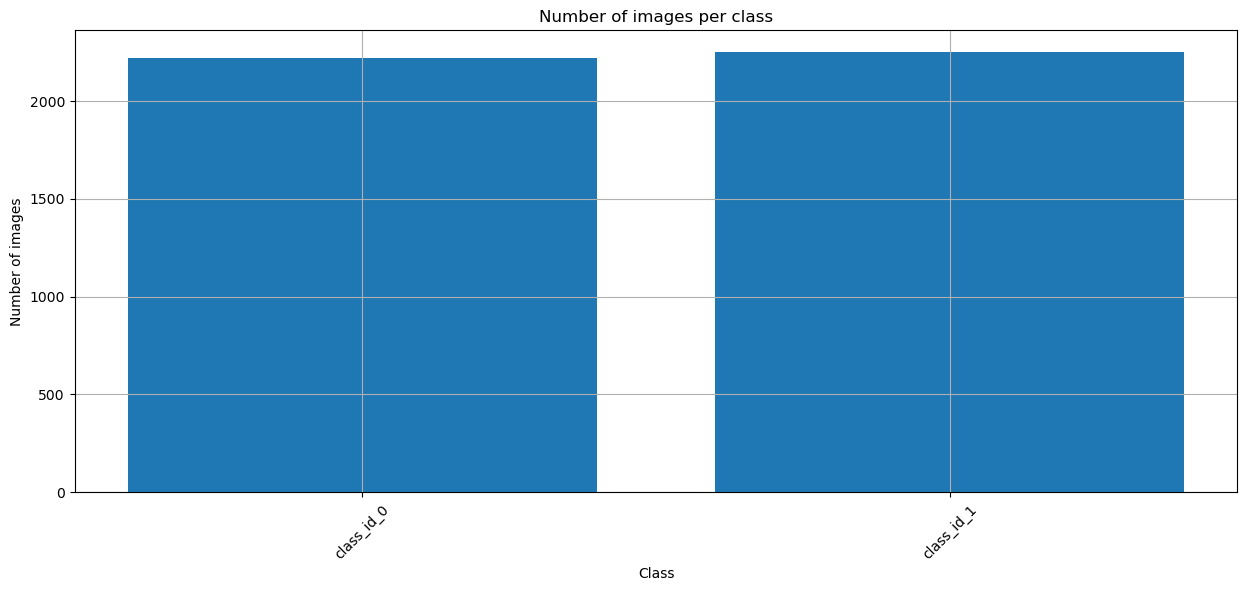

In [31]:

plt.tight_layout()
plt.show()
# Графік кількості зображень у класах
plt.bar(counts["class_name"], counts["num_images"])
plt.xticks(rotation=45)
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.title("Number of images per class")
plt.grid(True)
plt.show()
# Нормалізація пікселів до діапазону [0, 1]
images_norm = images.astype("float32") / 255.0

X_flat = images_norm.reshape(len(images_norm), -1)


In [9]:
# Для CNN потрібна форма: height, width, channels
X_cnn = images_norm[..., np.newaxis]

y = labels

print("X_flat:", X_flat.shape)
print("X_cnn:", X_cnn.shape)
print("y:", y.shape)
# Train / validation split
indices = np.arange(len(y))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

X_train_flat = X_flat[train_idx]
X_val_flat = X_flat[val_idx]

X_train_cnn = X_cnn[train_idx]
X_val_cnn = X_cnn[val_idx]

y_train = y[train_idx]
y_val = y[val_idx]

print("Train samples:", len(y_train))
print("Validation samples:", len(y_val))


X_flat: (4470, 784)
X_cnn: (4470, 28, 28, 1)
y: (4470,)
Train samples: 3576
Validation samples: 894


модель з одним нейроном

In [10]:
if num_classes != 2:
    print("Увага: один нейрон найкраще підходить для binary classification.")
    print("У вас класів:", num_classes)
single_neuron_model = Sequential([
    Input(shape=(X_train_flat.shape[1],)),
    Dense(1, activation="sigmoid")
])

single_neuron_model.summary()
single_neuron_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_single = single_neuron_model.fit(
    X_train_flat,
    y_train,
    validation_data=(X_val_flat, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │           785 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 785 (3.07 KB)

 Trainable params: 785 (3.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6091 - loss: 0.6625 - val_accuracy: 0.6588 - val_loss: 0.6350
Epoch 2/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 621us/step - accuracy: 0.6952 - loss: 0.6133 - val_accuracy: 0.7036 - val_loss: 0.5993
Epoch 3/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 602us/step - accuracy: 0.7343 - loss: 0.5814 - val_accuracy: 0.7371 - val_loss: 0.5698
Epoch 4/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 579us/step - accuracy: 0.7671 - loss: 0.5546 - val_accuracy: 0.7696 - val_loss: 0.5444
Epoch 5/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 561us/step - accuracy: 0.7911 - loss: 0.5311 - val_accuracy: 0.7841 - val_loss: 0.5221
Epoch 6/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 597us/step - accuracy: 0.8082 - loss: 0.5103 - val_accuracy: 0.8087 - val_loss: 0.5022
Epoch 7/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 571us/step - accuracy: 0.8230 - loss: 0.4916 - val_accuracy: 0.8221 - val_loss: 0.4844
Epoch 8/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step - accuracy: 0.8392 - loss: 0.4747 - va

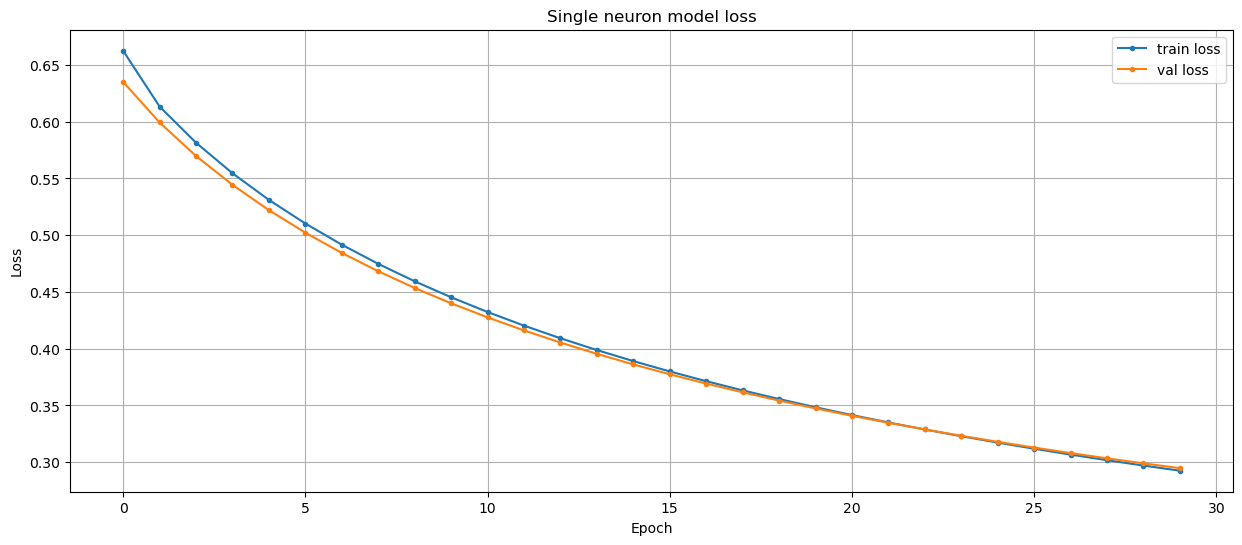

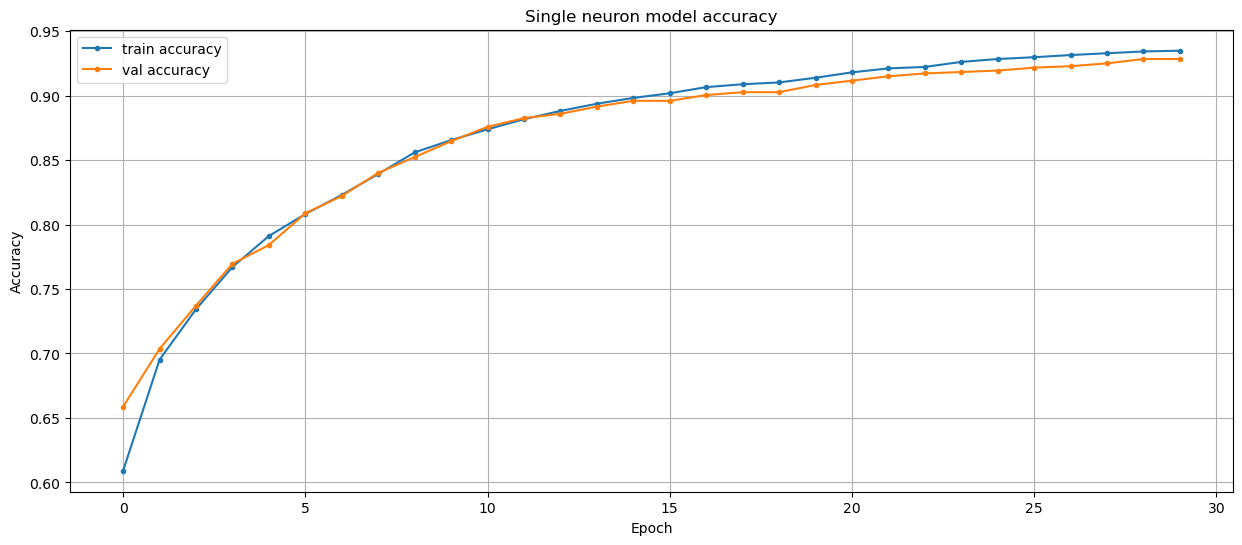

In [32]:
# Графік loss
plt.plot(history_single.history["loss"], ".-", label="train loss")
plt.plot(history_single.history["val_loss"], ".-", label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Single neuron model loss")
plt.grid(True)
plt.legend()
plt.show()
# Графік accuracy
plt.plot(history_single.history["accuracy"], ".-", label="train accuracy")
plt.plot(history_single.history["val_accuracy"], ".-", label="val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Single neuron model accuracy")
plt.grid(True)
plt.legend()
plt.show()


In [12]:
# Оцінка accuracy
single_loss, single_acc = single_neuron_model.evaluate(X_val_flat, y_val, verbose=0)

print("Single neuron validation accuracy:", single_acc)
# Передбачення
single_probs = single_neuron_model.predict(X_val_flat).ravel()
single_preds = (single_probs >= 0.5).astype(int)


Single neuron validation accuracy: 0.9284116625785828
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 611us/step


Accuracy: 0.9284116331096197

              precision    recall  f1-score   support

  class_id_0       0.92      0.94      0.93       444
  class_id_1       0.94      0.92      0.93       450

    accuracy                           0.93       894
   macro avg       0.93      0.93      0.93       894
weighted avg       0.93      0.93      0.93       894



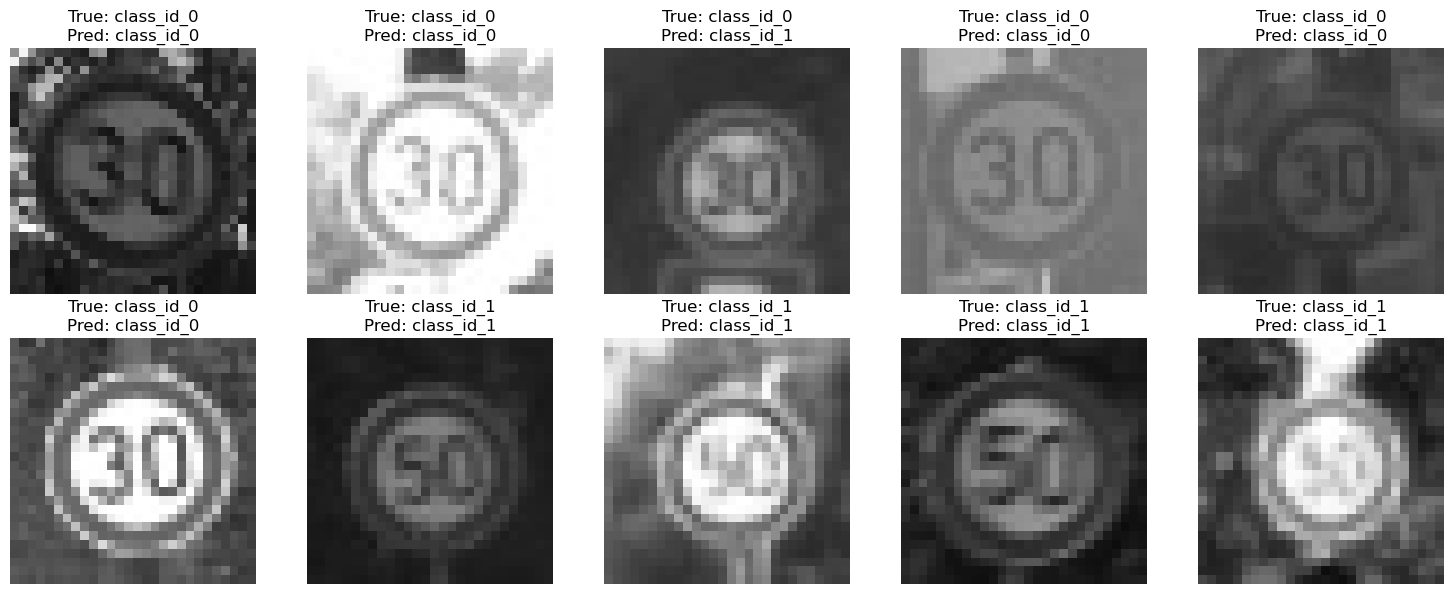

In [18]:

print("Accuracy:", accuracy_score(y_val, single_preds))
print()
print(classification_report(y_val, single_preds, target_names=class_names))
# Візуалізація передбачень
plt.figure(figsize=(15, 6))

for cnt, idx in enumerate(np.random.choice(len(X_val_flat), size=min(10, len(X_val_flat)), replace=False)):
    plt.subplot(2, 5, cnt + 1)
    plt.imshow(X_val_cnn[idx].squeeze(), cmap="gray", vmin=0, vmax=1)
    plt.title(f"True: {class_names[y_val[idx]]}\nPred: {class_names[single_preds[idx]]}")
    plt.axis("off")

    
plt.tight_layout()
plt.show()


Варіант 1: Dense Neural Network


In [19]:
if num_classes == 2:
    output_units = 1
    output_activation = "sigmoid"
    loss_function = "binary_crossentropy"
else:
    output_units = num_classes
    output_activation = "softmax"
    loss_function = "sparse_categorical_crossentropy"
dense_model = Sequential([
    Input(shape=(X_train_flat.shape[1],)),
    
    Dense(256, activation="relu"),
    Dropout(0.3),
    
    Dense(128, activation="relu"),
    Dropout(0.3),
    
    Dense(64, activation="relu"),
    
    Dense(output_units, activation=output_activation)
])

dense_model.summary()
dense_model.compile(
    optimizer="adam",
    loss=loss_function,
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=10,
    restore_best_weights=True,
    mode="max"
)

history_dense = dense_model.fit(
    X_train_flat,
    y_train,
    validation_data=(X_val_flat, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)
# Accuracy для Dense model
dense_loss, dense_acc = dense_model.evaluate(X_val_flat, y_val, verbose=0)



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,177 (946.00 KB)

 Trainable params: 242,177 (946.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5909 - loss: 0.6824 - val_accuracy: 0.6879 - val_loss: 0.6229
Epoch 2/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6706 - loss: 0.6126 - val_accuracy: 0.7841 - val_loss: 0.4806
Epoch 3/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7671 - loss: 0.4987 - val_accuracy: 0.8725 - val_loss: 0.3315
Epoch 4/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8305 - loss: 0.3829 - val_accuracy: 0.9016 - val_loss: 0.2650
Epoch 5/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8535 - loss: 0.3481 - val_accuracy: 0.9116 - val_loss: 0.2445
Epoch 6/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8638 - loss: 0.3250 - val_accuracy: 0.8680 - val_loss: 0.2979
Epoch 7/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8672 - loss: 0.3171 - val_accuracy: 0.9150 - val_loss: 0.2191
Epoch 8/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8644 - loss: 0.3038 - val_accu

Dense model validation accuracy: 0.9519015550613403


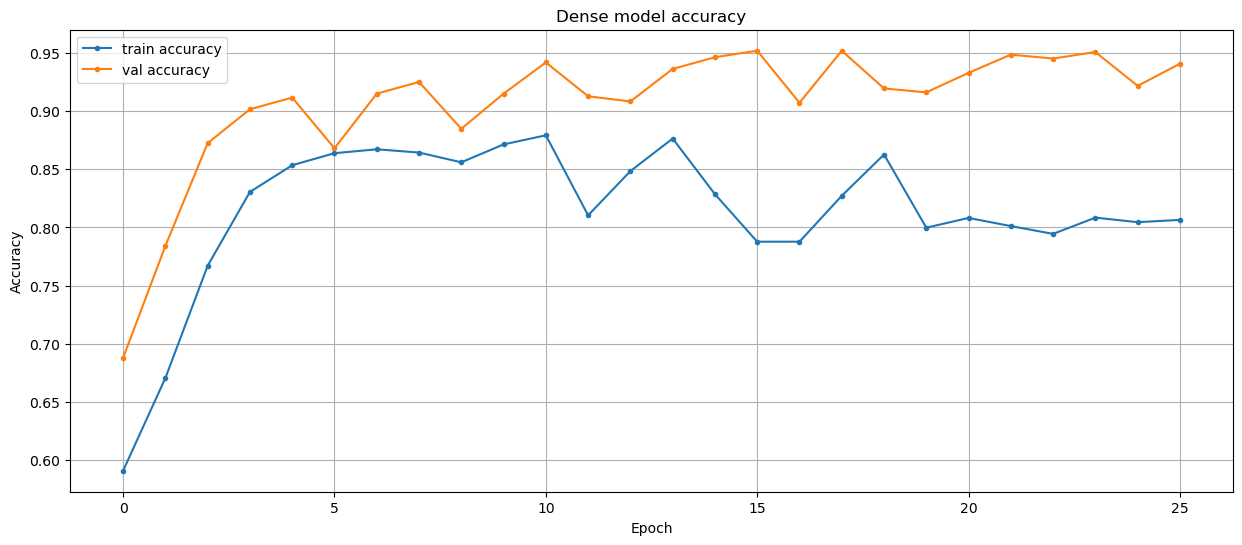

In [20]:
print("Dense model validation accuracy:", dense_acc)
plt.plot(history_dense.history["accuracy"], ".-", label="train accuracy")
plt.plot(history_dense.history["val_accuracy"], ".-", label="val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Dense model accuracy")
plt.grid(True)
plt.legend()
plt.show()


сильніший варіант: CNN model

In [21]:

cnn_model = Sequential([
    Input(shape=X_train_cnn.shape[1:]),
    
    Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
    MaxPooling2D(pool_size=(2, 2)),
    
    Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
    MaxPooling2D(pool_size=(2, 2)),
    
    Conv2D(128, kernel_size=(3, 3), activation="relu", padding="same"),
    MaxPooling2D(pool_size=(2, 2)),
    
    Flatten(),
    
    Dense(128, activation="relu"),
    Dropout(0.4),
    
    Dense(output_units, activation=output_activation)
])

cnn_model.summary()
cnn_model.compile(
    optimizer="adam",
    loss=loss_function,
    metrics=["accuracy"]
)

early_stop_cnn = EarlyStopping(
    monitor="val_accuracy",
    patience=10,
    restore_best_weights=True,
    mode="max"
)

history_cnn = cnn_model.fit(
    X_train_cnn,
    y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_cnn],
    verbose=1
)
cnn_loss, cnn_acc = cnn_model.evaluate(X_val_cnn, y_val, verbose=0)



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 240,385 (939.00 KB)

 Trainable params: 240,385 (939.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6096 - loss: 0.6560 - val_accuracy: 0.7349 - val_loss: 0.5642
Epoch 2/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8926 - loss: 0.2716 - val_accuracy: 0.9765 - val_loss: 0.0857
Epoch 3/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9790 - loss: 0.0749 - val_accuracy: 0.9911 - val_loss: 0.0345
Epoch 4/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9930 - loss: 0.0350 - val_accuracy: 0.9922 - val_loss: 0.0235
Epoch 5/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9955 - loss: 0.0197 - val_accuracy: 0.9888 - val_loss: 0.0219
Epoch 6/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9961 - loss: 0.0142 - val_accuracy: 0.9933 - val_loss: 0.0133
Epoch 7/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9980 - loss: 0.0070 - val_accuracy: 0.9933 - val_loss: 0.0218
Epoch 8/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9994 - loss: 0.0049 - 

CNN validation accuracy: 0.9966443181037903


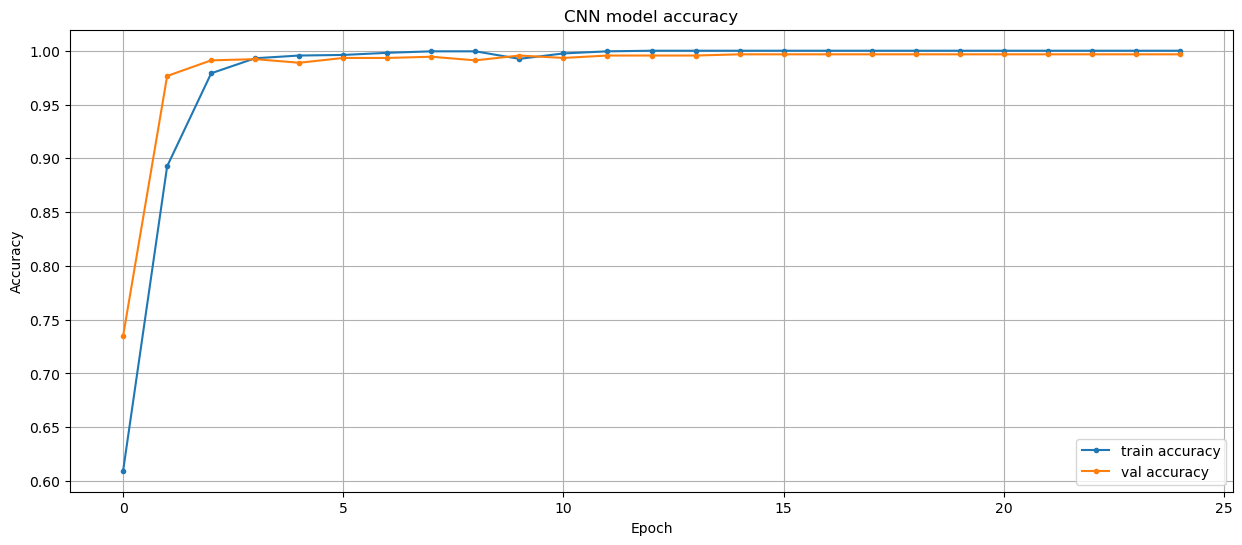

In [22]:
print("CNN validation accuracy:", cnn_acc)
plt.plot(history_cnn.history["accuracy"], ".-", label="train accuracy")
plt.plot(history_cnn.history["val_accuracy"], ".-", label="val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN model accuracy")
plt.grid(True)
plt.legend()
plt.show()


In [23]:
# Передбачення CNN
cnn_raw_preds = cnn_model.predict(X_val_cnn)

if num_classes == 2:
    cnn_preds = (cnn_raw_preds.ravel() >= 0.5).astype(int)
else:
    cnn_preds = np.argmax(cnn_raw_preds, axis=1)

print("CNN accuracy:", accuracy_score(y_val, cnn_preds))
print()
print(classification_report(y_val, cnn_preds, target_names=class_names))


28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
CNN accuracy: 0.9966442953020134

              precision    recall  f1-score   support

  class_id_0       1.00      1.00      1.00       444
  class_id_1       1.00      1.00      1.00       450

    accuracy                           1.00       894
   macro avg       1.00      1.00      1.00       894
weighted avg       1.00      1.00      1.00       894



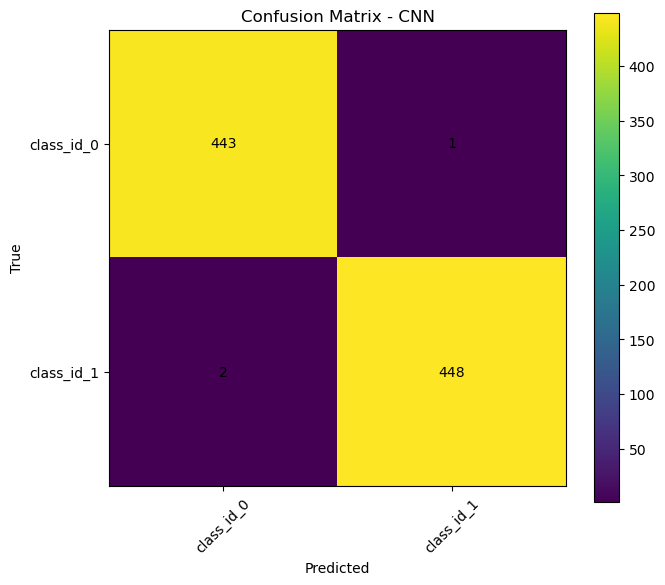

Results:
Single neuron accuracy: 0.9284116625785828
Dense model accuracy: 0.9519015550613403
CNN model accuracy: 0.9966443181037903


In [24]:
# Confusion matrix
cm = confusion_matrix(y_val, cnn_preds)

plt.figure(figsize=(7, 6))
plt.imshow(cm)
plt.title("Confusion Matrix - CNN")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()

plt.xticks(range(num_classes), class_names, rotation=45)
plt.yticks(range(num_classes), class_names)

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()
# Порівняння моделей
print("Results:")
print("Single neuron accuracy:", single_acc)
print("Dense model accuracy:", dense_acc)
print("CNN model accuracy:", cnn_acc)


In [25]:
best_acc = max(single_acc, dense_acc, cnn_acc)

if best_acc == single_acc:
    best_model_name = "Single neuron"
elif best_acc == dense_acc:
    best_model_name = "Dense model"
else:
    best_model_name = "CNN model"

print()
print("Best model:", best_model_name)
print("Maximum validation accuracy:", best_acc)



Best model: CNN model
Maximum validation accuracy: 0.9966443181037903


In [27]:
print(f"Accuracy with one neuron: {single_acc:.4f}")
print(f"Maximum accuracy achieved: {best_acc:.4f} using {best_model_name}")


Accuracy with one neuron: 0.9284
Maximum accuracy achieved: 0.9966 using CNN model
